# 2 — CLIP 텍스트 기반 이미지 검색



## 1. 실습 목표

- 사전학습된 CLIP 모델을 불러온다.
- 이미지와 텍스트를 모델 입력 형식으로 전처리한다.
- 이미지·텍스트 임베딩을 추출하고 코사인 유사도를 계산한다.
- 결과를 숫자와 그래프로 확인한다.

**주의:** 최초 실행 시 모델 가중치를 다운로드하므로 인터넷 연결이 필요하다. GPU가 없어도 작은 예제는 CPU에서 실행할 수 있지만, 처리 속도는 느릴 수 있다.

In [ ]:
# 필요한 라이브러리를 설치한다.
# 이미 설치되어 있다면 이 셀은 생략해도 된다.
# !uv add torch torchvision transformers pillow numpy matplotlib

In [1]:
# 이미지 처리, 수치 계산, 시각화, PyTorch, Hugging Face 모델 클래스를 불러온다.
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

# GPU가 사용 가능하면 GPU를 선택하고, 그렇지 않으면 CPU를 사용한다.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("실행 장치:", device)

# CLIP의 공개 사전학습 체크포인트를 지정한다.
# 이 모델은 이미지와 텍스트를 같은 임베딩 공간에서 비교하도록 학습되어 있다.
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

# Processor는 이미지 크기 조정·정규화와 텍스트 토큰화를 처리한다.
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

# Model은 학습된 가중치를 포함한다.
model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)

# 이번 수업은 모델을 새로 학습하는 것이 아니라 추론하는 과정이므로 eval 모드로 전환한다.
model.eval()

print("CLIP 모델 로드 완료")

c:\lab\llm-workspace\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


실행 장치: cpu


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 18176.14it/s]

CLIP 모델 로드 완료


## 2. 실습용 이미지 준비

아래 코드는 인터넷에 연결된 환경에서 공개 이미지 하나를 불러오는 예시이다. 외부 이미지 다운로드가 막힌 환경에서는 `Image.open("내_이미지_경로.jpg")`로 본인 이미지 파일을 불러온다.

모델 입력은 RGB 이미지여야 하므로 `convert("RGB")`를 사용한다.

In [14]:
import platform
# 1. OS별 한글 폰트 설정
if platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:  # Linux (Colab, Ubuntu 등)
    plt.rcParams["font.family"] = "NanumGothic"

# 2. 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

이미지를 불러왔다.


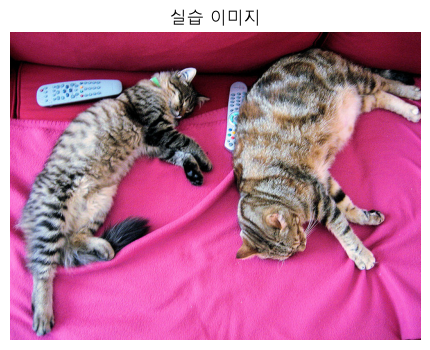

In [15]:
from urllib.request import urlopen

# 공개 예시 이미지 URL이다. 네트워크 정책에 따라 다운로드가 차단될 수 있다.
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"

try:
    with urlopen(IMAGE_URL, timeout=20) as response:
        image = Image.open(response).convert("RGB")
    print("이미지를 불러왔다.")
except Exception as exc:
    # 네트워크 실패 시 로컬 이미지 경로를 지정하도록 오류를 명확히 안내한다.
    raise RuntimeError(
        "예시 이미지를 다운로드하지 못했다. 인터넷 연결을 확인하거나 "
        "IMAGE_URL 대신 로컬 이미지 파일을 Image.open()으로 불러오도록 수정한다."
    ) from exc

plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.axis("off")
plt.title("실습 이미지")
plt.show()

## 1. 텍스트로 이미지 검색하기

이미지 검색 시스템에서는 미리 이미지 임베딩을 계산해 저장해 두고, 사용자가 입력한 텍스트 임베딩과 비교할 수 있다. 

In [16]:
# 실습용 이미지 파일을 이 목록에 지정한다.
# URL 다운로드 대신 로컬 파일을 사용하면 수업 환경에서 더 안정적으로 재현할 수 있다.
IMAGE_PATHS = [
    "image/cat.jpg",
    "image/dog.jpg",
    "image/car.jpg",
]

gallery = []
for path in IMAGE_PATHS:
    try:
        gallery.append((path, Image.open(path).convert("RGB")))
    except Exception as exc:
        print(f"이미지를 열지 못함: {path} / {exc}")

print("갤러리 이미지 수:", len(gallery))

갤러리 이미지 수: 3


In [20]:
import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# 이미지 갤러리 임베딩 계산
# ------------------------------------------------------------
#
# 실제 서비스에서는 이미지 임베딩을 매번 계산하지 않고
# 한 번 계산한 후 파일 또는 Vector DB에 저장하여
# 재사용하는 것이 일반적이다.
# ------------------------------------------------------------

if gallery:

    # --------------------------------------------------------
    # 1. gallery에서 이미지만 가져온다.
    # --------------------------------------------------------
    #
    # gallery 구조 예:
    #
    # [
    #     ("dog.jpg", PIL.Image),
    #     ("cat.jpg", PIL.Image),
    #     ("car.jpg", PIL.Image)
    # ]
    #
    # item[1]이 실제 PIL 이미지라고 가정한다.
    # --------------------------------------------------------

    gallery_images = [
        item[1]
        for item in gallery
    ]


    # --------------------------------------------------------
    # 2. CLIP Processor로 이미지 전처리
    # --------------------------------------------------------
    #
    # Processor는 이미지를 CLIP 모델이 입력받을 수 있도록
    #
    # Resize
    #   ↓
    # Crop
    #   ↓
    # Tensor 변환
    #   ↓
    # Normalize
    #
    # 과정을 수행한다.
    #
    # 결과:
    #
    # image_inputs["pixel_values"]
    #
    # shape 예:
    #
    # (3, 3, 224, 224)
    #
    # 첫 번째 3 → 이미지 개수
    # 두 번째 3 → RGB Channel
    # --------------------------------------------------------

    image_inputs = processor(
        images=gallery_images,
        return_tensors="pt"
    )


    # --------------------------------------------------------
    # 3. 입력 Tensor를 모델과 같은 장치로 이동
    # --------------------------------------------------------
    #
    # 예:
    #
    # model        → cuda
    # pixel_values → cuda
    #
    # 또는
    #
    # model        → mps
    # pixel_values → mps
    #
    # --------------------------------------------------------

    image_inputs = {
        key: value.to(device)
        for key, value in image_inputs.items()
    }


    # --------------------------------------------------------
    # 4. 이미지 특징 추출
    # --------------------------------------------------------
    #
    # get_image_features()
    #
    # 이미지의 CLIP Feature를 가져온다.
    #
    # 현재 설치된 transformers 환경에서는
    # Tensor가 직접 반환되지 않고
    #
    # BaseModelOutputWithPooling
    #
    # 객체가 반환되고 있다.
    # --------------------------------------------------------

    with torch.no_grad():

        image_outputs = model.get_image_features(
            pixel_values=image_inputs["pixel_values"]
        )


    # --------------------------------------------------------
    # 5. 반환 자료형 확인
    # --------------------------------------------------------

    print(
        "get_image_features 반환 타입:",
        type(image_outputs)
    )


    # --------------------------------------------------------
    # 6. 실제 이미지 Feature Tensor 가져오기
    # --------------------------------------------------------
    #
    # transformers 버전에 따라 반환 형태가 다를 수 있으므로
    # 두 경우를 모두 처리한다.
    #
    #
    # [경우 1]
    #
    # Tensor가 직접 반환되는 경우
    #
    # image_outputs
    #      ↓
    # gallery_features
    #
    #
    # [경우 2]
    #
    # BaseModelOutputWithPooling이 반환되는 경우
    #
    # image_outputs
    #      ↓
    # pooler_output
    #      ↓
    # gallery_features
    #
    #
    # 현재 사용자의 환경은 경우 2이다.
    # --------------------------------------------------------

    if isinstance(image_outputs, torch.Tensor):

        gallery_features = image_outputs

    else:

        gallery_features = image_outputs.pooler_output


    # --------------------------------------------------------
    # 7. Feature 크기 확인
    # --------------------------------------------------------
    #
    # 현재 모델:
    #
    # openai/clip-vit-base-patch32
    #
    # 최종 CLIP 임베딩 차원은 일반적으로 512이다.
    #
    # 예:
    #
    # 이미지 3장
    #
    # gallery_features.shape
    #
    # torch.Size([3, 512])
    #
    # --------------------------------------------------------

    print(
        "정규화 전 임베딩 크기:",
        tuple(gallery_features.shape)
    )


    # --------------------------------------------------------
    # 8. L2 Normalization
    # --------------------------------------------------------
    #
    # 각 이미지 임베딩 벡터의 길이를 1로 만든다.
    #
    #                    x
    # normalize(x) = -----------
    #                  ||x||₂
    #
    #
    # 예:
    #
    # 원래 벡터
    #
    # [2, 3, 4, ...]
    #
    #       ↓
    #
    # L2 Normalize
    #
    #       ↓
    #
    # 길이가 1인 벡터
    #
    #
    # 이미지와 텍스트를 모두 L2 Normalize하면
    # 두 벡터의 내적을 이용하여
    # Cosine Similarity를 계산할 수 있다.
    # --------------------------------------------------------

    gallery_features = F.normalize(
        gallery_features,
        p=2,
        dim=-1
    )


    # --------------------------------------------------------
    # 9. 최종 결과 확인
    # --------------------------------------------------------

    print(
        "갤러리 임베딩 크기:",
        tuple(gallery_features.shape)
    )

    print(
        "갤러리 임베딩 dtype:",
        gallery_features.dtype
    )

    print(
        "갤러리 임베딩 device:",
        gallery_features.device
    )


    # --------------------------------------------------------
    # 10. 정규화가 제대로 되었는지 확인
    # --------------------------------------------------------
    #
    # L2 Normalize를 했으므로
    # 각 이미지 벡터의 norm은 약 1.0이 되어야 한다.
    #
    # --------------------------------------------------------

    vector_norms = gallery_features.norm(
        p=2,
        dim=-1
    )

    print(
        "각 이미지 벡터의 길이:",
        vector_norms
    )


else:

    print(
        "IMAGE_PATHS에 실제 이미지 파일 경로를 추가한다."
    )

get_image_features 반환 타입: <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
정규화 전 임베딩 크기: (3, 512)
갤러리 임베딩 크기: (3, 512)
갤러리 임베딩 dtype: torch.float32
갤러리 임베딩 device: cpu
각 이미지 벡터의 길이: tensor([1.0000, 1.0000, 1.0000])


In [22]:
def search_images_by_text(query, top_k=3):
    """
    텍스트 질의와 가장 유사한 갤러리 이미지를 검색한다.

    Parameters
    ----------
    query : str
        검색할 텍스트 문장

        예:
        "a cat sitting on a sofa"
        "a white dog"
        "a red car"

    top_k : int
        유사도가 높은 이미지 몇 개를 반환할지 지정한다.

    Returns
    -------
    results : list
        검색 결과를 리스트 형태로 반환한다.
    """

    # --------------------------------------------------------
    # 1. 갤러리 이미지가 존재하는지 확인
    # --------------------------------------------------------
    #
    # gallery에는 미리 불러온 이미지가 저장되어 있어야 한다.
    #
    # 예:
    #
    # gallery = [
    #     ("dog.jpg", dog_image),
    #     ("cat.jpg", cat_image),
    #     ("car.jpg", car_image)
    # ]
    #
    # --------------------------------------------------------

    if not gallery:
        raise ValueError(
            "먼저 IMAGE_PATHS에 이미지 경로를 추가해야 한다."
        )


    # --------------------------------------------------------
    # 2. 검색 문장을 CLIP 입력 형태로 변환
    # --------------------------------------------------------
    #
    # 예:
    #
    # query
    #
    # "a cat sitting on a sofa"
    #
    #       ↓
    #
    # CLIPProcessor
    #
    #       ↓
    #
    # input_ids
    # attention_mask
    #
    # --------------------------------------------------------

    query_inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )


    # --------------------------------------------------------
    # 3. 입력 Tensor를 모델과 동일한 device로 이동
    # --------------------------------------------------------

    query_inputs = {
        key: value.to(device)
        for key, value in query_inputs.items()
    }


    # --------------------------------------------------------
    # 4. CLIP Text Feature 추출
    # --------------------------------------------------------
    #
    # 현재는 학습이 아니라 검색이므로
    # gradient를 계산할 필요가 없다.
    #
    # 따라서 torch.no_grad()를 사용한다.
    #
    # --------------------------------------------------------

    with torch.no_grad():

        text_outputs = model.get_text_features(

            input_ids=query_inputs["input_ids"],

            attention_mask=query_inputs["attention_mask"]
        )


    # --------------------------------------------------------
    # 5. 반환 자료형 확인
    # --------------------------------------------------------
    #
    # 현재 transformers 환경에서는
    #
    # get_text_features()
    #
    # 결과가 Tensor가 아니라
    #
    # BaseModelOutputWithPooling
    #
    # 객체로 반환되고 있다.
    #
    # --------------------------------------------------------

    print(
        "get_text_features 반환 타입:",
        type(text_outputs)
    )


    # --------------------------------------------------------
    # 6. 실제 텍스트 임베딩 Tensor 가져오기
    # --------------------------------------------------------
    #
    # transformers 버전에 따라 반환 형태가 다를 수 있으므로
    # 두 경우를 모두 처리한다.
    #
    #
    # 경우 1
    # --------------------------------------------------------
    #
    # get_text_features()
    #
    #       ↓
    #
    # Tensor
    #
    #
    # 경우 2
    # --------------------------------------------------------
    #
    # get_text_features()
    #
    #       ↓
    #
    # BaseModelOutputWithPooling
    #
    #       ↓
    #
    # pooler_output
    #
    # --------------------------------------------------------

    if isinstance(text_outputs, torch.Tensor):

        query_features = text_outputs

    else:

        query_features = text_outputs.pooler_output


    # --------------------------------------------------------
    # 7. 텍스트 임베딩 크기 확인
    # --------------------------------------------------------
    #
    # 정상적인 경우:
    #
    # query_features.shape
    #
    # (1, 512)
    #
    #
    # 1
    # → 검색 문장 1개
    #
    # 512
    # → CLIP 공유 임베딩 차원
    #
    # --------------------------------------------------------

    print(
        "텍스트 임베딩 크기:",
        tuple(query_features.shape)
    )


    # --------------------------------------------------------
    # 8. L2 Normalization
    # --------------------------------------------------------
    #
    # 텍스트 임베딩 벡터의 길이를 1로 만든다.
    #
    #
    #                  x
    # x_normalized = ------
    #                ||x||₂
    #
    #
    # 이미지 임베딩도 앞에서 동일하게
    # L2 Normalize를 수행하였다.
    #
    # 따라서
    #
    # normalized text embedding
    #
    #            @
    #
    # normalized image embedding
    #
    # 을 계산하면 Cosine Similarity가 된다.
    #
    # --------------------------------------------------------

    query_features = F.normalize(
        query_features,
        p=2,
        dim=-1
    )


    # --------------------------------------------------------
    # 9. 이미지와 텍스트 임베딩 차원 확인
    # --------------------------------------------------------
    #
    # 매우 중요한 부분이다.
    #
    # 예:
    #
    # query_features
    # (1, 512)
    #
    # gallery_features
    # (3, 512)
    #
    # 두 임베딩의 마지막 차원이 동일해야 한다.
    #
    # --------------------------------------------------------

    print(
        "텍스트 임베딩:",
        tuple(query_features.shape)
    )

    print(
        "이미지 임베딩:",
        tuple(gallery_features.shape)
    )


    # --------------------------------------------------------
    # 10. 텍스트 ↔ 이미지 Cosine Similarity 계산
    # --------------------------------------------------------
    #
    # query_features
    #
    # (1, 512)
    #
    #
    # gallery_features
    #
    # (N, 512)
    #
    #
    # transpose
    #
    # gallery_features.T
    #
    # (512, N)
    #
    #
    # 행렬곱:
    #
    # (1,512) @ (512,N)
    #
    #       ↓
    #
    # (1,N)
    #
    #
    # 결과:
    #
    # 검색 문장과 각각의 이미지 사이의
    # Cosine Similarity
    #
    # --------------------------------------------------------

    scores = (
        query_features
        @
        gallery_features.T
    )[0]


    # --------------------------------------------------------
    # 11. 유사도가 높은 순서대로 정렬
    # --------------------------------------------------------
    #
    # descending=True
    #
    # 큰 값 → 작은 값 순서
    #
    # --------------------------------------------------------

    order = torch.argsort(
        scores,
        descending=True
    )[:top_k]


    # --------------------------------------------------------
    # 12. 검색 결과 생성
    # --------------------------------------------------------

    results = []


    for rank, idx in enumerate(
        order,
        start=1
    ):

        i = int(idx)


        results.append({

            # 검색 순위
            "rank": rank,

            # 이미지 파일 경로
            "path": gallery[i][0],

            # Cosine Similarity
            "score": float(
                scores[i].cpu()
            ),

            # PIL Image
            "image": gallery[i][1]

        })


    # --------------------------------------------------------
    # 13. 검색 결과 반환
    # --------------------------------------------------------

    return results


# ============================================================
# 이미지 검색 실행
# ============================================================

results = search_images_by_text(
    "a cat sitting on a sofa",
    top_k=3
)


# ============================================================
# 검색 결과 출력
# ============================================================

print("\n" + "=" * 70)
print("이미지 검색 결과")
print("=" * 70)


for result in results:

    print(
        f"순위: {result['rank']} | "
        f"유사도: {result['score']:.4f} | "
        f"파일: {result['path']}"
    )

get_text_features 반환 타입: <class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>
텍스트 임베딩 크기: (1, 512)
텍스트 임베딩: (1, 512)
이미지 임베딩: (3, 512)

이미지 검색 결과
순위: 1 | 유사도: 0.2884 | 파일: image/cat.jpg
순위: 2 | 유사도: 0.1711 | 파일: image/dog.jpg
순위: 3 | 유사도: 0.0966 | 파일: image/car.jpg


## 2. 검색 결과 시각화

갤러리 이미지가 준비되면 아래 코드를 실행해 검색 순위를 시각적으로 확인한다.

In [24]:
from pathlib import Path

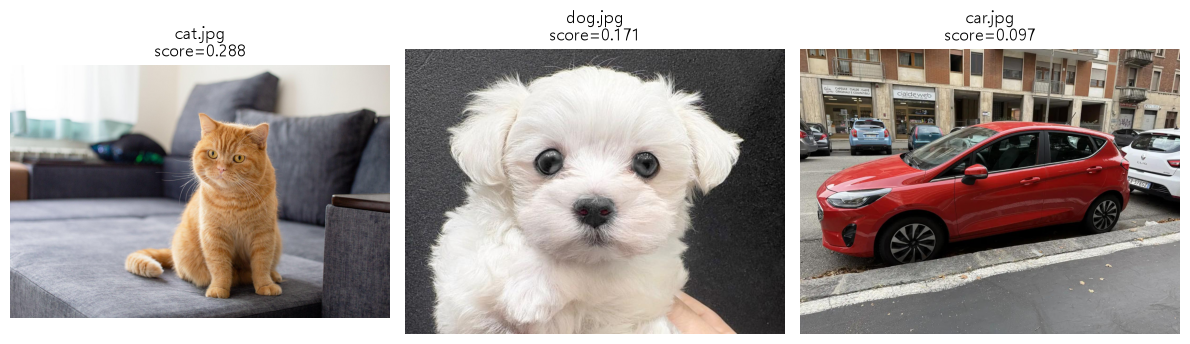

In [25]:
# 위에서 results를 생성한 뒤 실행한다.
# results = search_images_by_text("a cat", top_k=3)

if "results" in globals() and results:
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
    if len(results) == 1:
        axes = [axes]
    for ax, item in zip(axes, results):
        ax.imshow(item["image"])
        ax.set_title(f'{Path(item["path"]).name}\nscore={item["score"]:.3f}')
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("이미지 경로를 설정하고 검색 코드를 실행한 뒤 이 셀을 실행한다.")

## 3. 확장 과제

1. 이미지가 100장 이상일 때 미리 계산한 임베딩을 저장하고 다시 불러오는 기능을 구현한다.
2. 이미지 검색과 이미지-텍스트 검색의 차이를 설명한다.
3. CLIP의 유사도 점수만으로 검색 결과가 사실적으로 정확하다고 보장할 수 없는 이유를 작성한다.

<details>
<summary>정답 보기</summary>

```python


# ============================================================
# CLIP 이미지-텍스트 검색 확장 실습
# ============================================================
#
# 데이터셋 : Hugging Face CIFAR-10
# 모델     : openai/clip-vit-base-patch32
#
# 구현 내용
#
# 1. Hugging Face에서 CIFAR-10 이미지를 가져온다.
# 2. automobile / cat / dog 이미지를 각각 100장씩 가져온다.
# 3. 총 300장의 이미지 임베딩을 CLIP으로 계산한다.
# 4. 계산한 이미지 임베딩을 파일로 저장한다.
# 5. 저장된 임베딩을 다시 불러온다.
# 6. 자연어 검색 문장을 CLIP 텍스트 임베딩으로 변환한다.
# 7. 이미지 임베딩과 텍스트 임베딩의 Cosine Similarity를 계산한다.
# 8. 가장 유사한 Top-K 이미지를 검색한다.
# 9. 검색 결과를 시각화한다.
# 10. 검색 결과의 클래스 일치 여부를 확인한다.
#
# 필요 라이브러리
#
# uv add -U torch transformers datasets pillow matplotlib
# ============================================================


# ------------------------------------------------------------
# 1. 라이브러리
# ------------------------------------------------------------

import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import CLIPProcessor, CLIPModel


# ------------------------------------------------------------
# 2. 실행 장치 설정
# ------------------------------------------------------------
#
# NVIDIA GPU → CUDA
# Apple Silicon → MPS
# 그 외 → CPU
# ------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print("=" * 70)
print("1. 실행 환경")
print("=" * 70)

print("PyTorch :", torch.__version__)
print("Device  :", device)


# ------------------------------------------------------------
# 3. 기본 설정
# ------------------------------------------------------------

MODEL_NAME = "openai/clip-vit-base-patch32"

# 사용할 클래스
TARGET_CLASSES = [
    "automobile",
    "cat",
    "dog"
]

# 클래스별 100장
NUM_PER_CLASS = 100

# 총 이미지 수
# 3 × 100 = 300장
TOTAL_IMAGES = NUM_PER_CLASS * len(TARGET_CLASSES)

# 한 번에 CLIP에 입력할 이미지 수
#
# 300장을 한꺼번에 GPU에 넣으면
# 메모리를 많이 사용할 수 있으므로
# batch 단위로 처리한다.
BATCH_SIZE = 32

# 계산된 임베딩을 저장할 파일
EMBEDDING_FILE = "cifar10_clip_embeddings.pt"


# ------------------------------------------------------------
# 4. Hugging Face CIFAR-10 데이터셋 가져오기
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. Hugging Face CIFAR-10 데이터셋")
print("=" * 70)

dataset = load_dataset(
    "uoft-cs/cifar10",
    split="test"
)

print(dataset)
print("전체 이미지 수 :", len(dataset))


# ------------------------------------------------------------
# 5. CIFAR-10 클래스 이름 확인
# ------------------------------------------------------------

class_names = dataset.features["label"].names

print("\nCIFAR-10 클래스")

for index, name in enumerate(class_names):
    print(f"{index:2d} → {name}")


# ------------------------------------------------------------
# 6. automobile / cat / dog 이미지 선택
# ------------------------------------------------------------
#
# 각 클래스에서 100장씩 선택한다.
#
# 결과:
#
# automobile → 100장
# cat        → 100장
# dog        → 100장
#
# 총 300장
# ------------------------------------------------------------

gallery = []

class_count = {
    class_name: 0
    for class_name in TARGET_CLASSES
}


for dataset_index, sample in enumerate(dataset):

    # 숫자 Label
    label_index = sample["label"]

    # 숫자 → 클래스 이름
    label_name = class_names[label_index]

    # 필요한 클래스가 아니면 건너뛴다.
    if label_name not in TARGET_CLASSES:
        continue

    # 이미 해당 클래스에서 100장을 가져왔다면 건너뛴다.
    if class_count[label_name] >= NUM_PER_CLASS:
        continue

    # CIFAR-10 이미지
    image = sample["img"].convert("RGB")

    # --------------------------------------------------------
    # gallery에 다음 정보를 저장한다.
    #
    # {
    #     "id"    : 원래 dataset index,
    #     "label" : 실제 클래스,
    #     "image" : PIL Image
    # }
    # --------------------------------------------------------

    gallery.append({
        "id": dataset_index,
        "label": label_name,
        "image": image
    })

    class_count[label_name] += 1

    # 모든 클래스가 100장씩 모였으면 종료
    if all(
        count >= NUM_PER_CLASS
        for count in class_count.values()
    ):
        break


print("\n" + "=" * 70)
print("3. Gallery 구성")
print("=" * 70)

for class_name in TARGET_CLASSES:
    print(
        f"{class_name:12s}: "
        f"{class_count[class_name]}장"
    )

print("-" * 30)
print("전체 :", len(gallery), "장")


# ------------------------------------------------------------
# 7. CLIP 모델과 Processor 불러오기
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. CLIP 모델 로딩")
print("=" * 70)

processor = CLIPProcessor.from_pretrained(
    MODEL_NAME
)

model = CLIPModel.from_pretrained(
    MODEL_NAME
)

model = model.to(device)

model.eval()

print("Model :", MODEL_NAME)


# ------------------------------------------------------------
# 8. CLIP 반환값에서 실제 Feature Tensor를 가져오는 함수
# ------------------------------------------------------------
#
# 현재 transformers 버전에 따라
#
# get_image_features()
# get_text_features()
#
# 반환값이 Tensor일 수도 있고
# BaseModelOutputWithPooling일 수도 있다.
#
# 따라서 두 경우를 모두 처리한다.
# ------------------------------------------------------------

def extract_feature_tensor(outputs):

    # Tensor가 직접 반환된 경우
    if isinstance(outputs, torch.Tensor):
        return outputs

    # BaseModelOutputWithPooling 등이 반환된 경우
    if hasattr(outputs, "pooler_output"):
        return outputs.pooler_output

    raise TypeError(
        f"지원하지 않는 CLIP 반환 타입입니다: {type(outputs)}"
    )


# ============================================================
# 과제 1
# 이미지 임베딩 계산 → 저장 → 다시 불러오기
# ============================================================


# ------------------------------------------------------------
# 9. 이미지 임베딩 계산 함수
# ------------------------------------------------------------
#
# 이미지가 100장 이상이면
# 모든 이미지를 한 번에 처리하지 않고
# Batch 단위로 처리하는 것이 좋다.
#
# 예:
#
# 300 images
#
#     ↓
#
# Batch 1 : 32
# Batch 2 : 32
# Batch 3 : 32
# ...
#
#     ↓
#
# 모든 Feature 연결
#
#     ↓
#
# (300, 512)
# ------------------------------------------------------------

def create_gallery_embeddings(
    gallery,
    batch_size=32
):

    all_features = []

    total = len(gallery)

    print("\n이미지 임베딩 계산 시작")


    # --------------------------------------------------------
    # batch_size 단위로 이미지 처리
    # --------------------------------------------------------

    for start in range(
        0,
        total,
        batch_size
    ):

        end = min(
            start + batch_size,
            total
        )

        # 현재 Batch
        batch_items = gallery[start:end]

        # PIL 이미지만 가져온다.
        batch_images = [
            item["image"]
            for item in batch_items
        ]


        # ----------------------------------------------------
        # CLIP Processor
        # ----------------------------------------------------

        image_inputs = processor(
            images=batch_images,
            return_tensors="pt"
        )


        # ----------------------------------------------------
        # Tensor를 device로 이동
        # ----------------------------------------------------

        pixel_values = (
            image_inputs["pixel_values"]
            .to(device)
        )


        # ----------------------------------------------------
        # Image Feature 계산
        # ----------------------------------------------------

        with torch.no_grad():

            image_outputs = (
                model.get_image_features(
                    pixel_values=pixel_values
                )
            )


        # ----------------------------------------------------
        # 실제 Tensor 추출
        # ----------------------------------------------------

        image_features = (
            extract_feature_tensor(
                image_outputs
            )
        )


        # ----------------------------------------------------
        # L2 Normalization
        # ----------------------------------------------------
        #
        # 각 이미지 임베딩 벡터의 길이를 1로 만든다.
        #
        # 이후 텍스트 임베딩도 동일하게 정규화하면
        # 두 벡터의 내적이 Cosine Similarity가 된다.
        # ----------------------------------------------------

        image_features = F.normalize(
            image_features,
            p=2,
            dim=-1
        )


        # ----------------------------------------------------
        # CPU로 이동 후 저장
        # ----------------------------------------------------
        #
        # 모든 Feature를 GPU에 계속 보관하면
        # GPU 메모리를 차지하므로 CPU로 이동한다.
        # ----------------------------------------------------

        all_features.append(
            image_features.cpu()
        )


        print(
            f"처리 완료 : "
            f"{end:3d}/{total}"
        )


    # --------------------------------------------------------
    # Batch별 Feature를 하나로 연결한다.
    # --------------------------------------------------------

    gallery_features = torch.cat(
        all_features,
        dim=0
    )

    return gallery_features


# ------------------------------------------------------------
# 10. 이미지 임베딩 계산
# ------------------------------------------------------------

gallery_features = create_gallery_embeddings(
    gallery,
    batch_size=BATCH_SIZE
)

print(
    "\n계산된 이미지 임베딩 크기:",
    tuple(gallery_features.shape)
)


# ------------------------------------------------------------
# 11. 임베딩 저장
# ------------------------------------------------------------
#
# 이미지 자체를 저장하는 것이 아니라
#
# - 이미지 ID
# - 실제 Label
# - 이미지 Feature
#
# 를 저장한다.
#
# 이미지 자체는 Hugging Face에서
# 다시 가져올 수 있기 때문에
# 여기서는 dataset index를 저장한다.
# ------------------------------------------------------------

save_data = {

    "model_name":
        MODEL_NAME,

    "dataset_name":
        "uoft-cs/cifar10",

    "dataset_split":
        "test",

    "ids": [
        item["id"]
        for item in gallery
    ],

    "labels": [
        item["label"]
        for item in gallery
    ],

    "features":
        gallery_features
}


torch.save(
    save_data,
    EMBEDDING_FILE
)


print("\n" + "=" * 70)
print("5. 임베딩 저장")
print("=" * 70)

print(
    "저장 파일 :",
    EMBEDDING_FILE
)

print(
    "파일 존재 :",
    os.path.exists(
        EMBEDDING_FILE
    )
)

print(
    "저장 Feature :",
    tuple(gallery_features.shape)
)


# ------------------------------------------------------------
# 12. 메모리에 있는 임베딩 삭제
# ------------------------------------------------------------
#
# 실제로 파일에서 다시 불러오는 것을 확인하기 위해
# 기존 변수를 삭제한다.
# ------------------------------------------------------------

del gallery_features


# ------------------------------------------------------------
# 13. 저장된 임베딩 다시 불러오기
# ------------------------------------------------------------

loaded_data = torch.load(
    EMBEDDING_FILE,
    map_location="cpu"
)


gallery_features = (
    loaded_data["features"]
    .to(device)
)

gallery_ids = loaded_data["ids"]

gallery_labels = loaded_data["labels"]


print("\n" + "=" * 70)
print("6. 저장된 임베딩 다시 Load")
print("=" * 70)

print(
    "Model :",
    loaded_data["model_name"]
)

print(
    "Dataset :",
    loaded_data["dataset_name"]
)

print(
    "Feature Shape :",
    tuple(gallery_features.shape)
)

print(
    "Image Count :",
    len(gallery_ids)
)


# ------------------------------------------------------------
# 14. 저장된 Feature가 정상적인지 확인
# ------------------------------------------------------------
#
# L2 Normalize를 했으므로
# 각 Feature의 벡터 길이는 약 1이어야 한다.
# ------------------------------------------------------------

print(
    "첫 번째 이미지 벡터 길이:",
    gallery_features[0]
    .norm()
    .item()
)


# ============================================================
# 과제 2
# Text → Image 검색 구현
# ============================================================


# ------------------------------------------------------------
# 15. 텍스트를 CLIP 임베딩으로 변환하는 함수
# ------------------------------------------------------------

def encode_text(query):

    # --------------------------------------------------------
    # 검색 문장
    #
    # 예:
    #
    # "a photo of a cat"
    #
    #       ↓
    #
    # CLIP Processor
    #
    #       ↓
    #
    # input_ids
    # attention_mask
    # --------------------------------------------------------

    query_inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )


    query_inputs = {
        key: value.to(device)
        for key, value
        in query_inputs.items()
    }


    # --------------------------------------------------------
    # Text Feature 계산
    # --------------------------------------------------------

    with torch.no_grad():

        text_outputs = (
            model.get_text_features(
                input_ids=
                    query_inputs["input_ids"],

                attention_mask=
                    query_inputs["attention_mask"]
            )
        )


    # --------------------------------------------------------
    # 실제 Feature Tensor 추출
    # --------------------------------------------------------

    text_features = (
        extract_feature_tensor(
            text_outputs
        )
    )


    # --------------------------------------------------------
    # L2 Normalize
    # --------------------------------------------------------

    text_features = F.normalize(
        text_features,
        p=2,
        dim=-1
    )

    return text_features


# ------------------------------------------------------------
# 16. Text → Image 검색 함수
# ------------------------------------------------------------

def search_images_by_text(
    query,
    top_k=5
):

    # top_k가 전체 이미지보다 큰 경우 방지
    top_k = min(
        top_k,
        len(gallery)
    )


    # --------------------------------------------------------
    # 검색 문장을 CLIP Text Embedding으로 변환
    # --------------------------------------------------------

    query_features = encode_text(
        query
    )


    print(
        "\nText Feature :",
        tuple(query_features.shape)
    )

    print(
        "Image Feature:",
        tuple(gallery_features.shape)
    )


    # --------------------------------------------------------
    # Cosine Similarity
    # --------------------------------------------------------
    #
    # query_features
    #
    # (1, 512)
    #
    #
    # gallery_features
    #
    # (300, 512)
    #
    #
    # gallery_features.T
    #
    # (512, 300)
    #
    #
    # 행렬곱
    #
    # (1,512) @ (512,300)
    #
    #       ↓
    #
    # (1,300)
    #
    #
    # 각 이미지와 검색 문장 사이의
    # Cosine Similarity가 계산된다.
    # --------------------------------------------------------

    scores = (
        query_features
        @
        gallery_features.T
    )[0]


    # --------------------------------------------------------
    # 유사도가 높은 이미지 Top-K 선택
    # --------------------------------------------------------

    values, indices = torch.topk(
        scores,
        k=top_k
    )


    results = []


    # --------------------------------------------------------
    # 검색 결과 생성
    # --------------------------------------------------------

    for rank, (
        score,
        index
    ) in enumerate(
        zip(values, indices),
        start=1
    ):

        i = index.item()


        results.append({

            "rank":
                rank,

            "gallery_index":
                i,

            "dataset_id":
                gallery_ids[i],

            "label":
                gallery_labels[i],

            "score":
                score.item(),

            "image":
                gallery[i]["image"]
        })


    return results


# ------------------------------------------------------------
# 17. 검색 결과 출력 함수
# ------------------------------------------------------------

def show_search_results(
    query,
    results
):

    print("\n" + "=" * 70)
    print("검색 결과")
    print("=" * 70)

    print(
        "검색어:",
        query
    )


    for result in results:

        print(

            f"{result['rank']}위 | "

            f"Label: "
            f"{result['label']:12s} | "

            f"Similarity: "
            f"{result['score']:.4f}"

        )


    # --------------------------------------------------------
    # 이미지 시각화
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        len(results),
        figsize=(
            3 * len(results),
            3
        )
    )


    # Top-1인 경우도 처리 가능하도록 한다.
    if len(results) == 1:
        axes = [axes]


    for ax, result in zip(
        axes,
        results
    ):

        ax.imshow(
            result["image"]
        )

        ax.set_title(

            f"Rank {result['rank']}\n"

            f"{result['label']}\n"

            f"sim="
            f"{result['score']:.3f}"
        )

        ax.axis("off")


    plt.suptitle(
        f'Query: "{query}"'
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 18. 실제 검색 실행
# ------------------------------------------------------------

query = "a photo of a cat"

results = search_images_by_text(
    query,
    top_k=5
)

show_search_results(
    query,
    results
)


# ============================================================
# 19. 다른 검색어도 테스트
# ============================================================

test_queries = [

    "a photo of a dog",

    "a photo of a car",

    "a cute cat",

    "a small dog",

    "an automobile"
]


for query in test_queries:

    results = search_images_by_text(
        query,
        top_k=5
    )

    show_search_results(
        query,
        results
    )


# ============================================================
# 20. 검색 결과 정량 평가
# ============================================================
#
# CIFAR-10에는 실제 Label이 존재한다.
#
# 따라서
#
# "a photo of a cat"
#
# 으로 검색했을 때
# Top-K 결과 중 실제 cat이 몇 장인지 확인할 수 있다.
#
# 이를 Precision@K 형태로 확인한다.
#
#                  관련 이미지 개수
# Precision@K = ------------------------
#                        K
#
# ============================================================

def evaluate_search(
    query,
    expected_label,
    top_k=10
):

    results = search_images_by_text(
        query,
        top_k=top_k
    )


    # --------------------------------------------------------
    # 정답 클래스와 일치하는 검색 결과 개수
    # --------------------------------------------------------

    correct = sum(

        result["label"]
        ==
        expected_label

        for result in results
    )


    precision = (
        correct
        /
        top_k
    )


    print("\n" + "=" * 70)

    print(
        f'Query : "{query}"'
    )

    print(
        "Expected Label :",
        expected_label
    )

    print(
        f"Correct : "
        f"{correct}/{top_k}"
    )

    print(
        f"Precision@{top_k} : "
        f"{precision:.2%}"
    )


    return precision


# ------------------------------------------------------------
# 21. 세 클래스 검색 성능 확인
# ------------------------------------------------------------

cat_precision = evaluate_search(
    "a photo of a cat",
    "cat",
    top_k=10
)


dog_precision = evaluate_search(
    "a photo of a dog",
    "dog",
    top_k=10
)


car_precision = evaluate_search(
    "a photo of a car",
    "automobile",
    top_k=10
)


# ------------------------------------------------------------
# 22. 최종 결과
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("최종 검색 평가")
print("=" * 70)

print(
    f"cat Precision@10 : "
    f"{cat_precision:.2%}"
)

print(
    f"dog Precision@10 : "
    f"{dog_precision:.2%}"
)

print(
    f"car Precision@10 : "
    f"{car_precision:.2%}"
)

```
</details>


<details>
<summary>정답 풀이</summary>

```python
**실제로 하나의 흐름으로 실행되도록** 구성하면 된다.

핵심 흐름은 다음과 같다.

```text
Hugging Face CIFAR-10
        ↓
이미지 300장 선택
        ↓
CLIP Image Encoder
        ↓
이미지 임베딩 계산
        ↓
gallery_embeddings.pt 저장
        ↓
저장된 임베딩 다시 Load
        ↓
텍스트 검색어
        ↓
CLIP Text Encoder
        ↓
Cosine Similarity
        ↓
Top-K 이미지 검색
        ↓
검색 결과 시각화
```


## 1. 임베딩을 저장하는 이유

300개의 이미지가 있다고 하자. 검색할 때마다 다음 과정을 반복하면 비효율적이다.

```text
검색어 입력
   ↓
300개 이미지 CLIP 처리
   ↓
300개 Image Embedding 계산
   ↓
Text Embedding 계산
   ↓
검색
```

이미지는 검색할 때마다 바뀌지 않으므로 이미지 임베딩을 **한 번만 계산**한다.

```text
최초 1회
────────────────────────

CIFAR-10 이미지 300장
        ↓
CLIP Image Encoder
        ↓
Image Embeddings
      (300, 512)
        ↓
L2 Normalize
        ↓
cifar10_clip_embeddings.pt
        ↓
      저장
```

검색할 때는 다음 과정만 수행한다.

```text
"a photo of a cat"
        ↓
CLIP Text Encoder
        ↓
Text Embedding
      (1, 512)
        ↓
L2 Normalize
        ↓
        │
        │ Cosine Similarity
        ▼
저장된 Image Embeddings
      (300, 512)
        ↓
     Top-K
        ↓
검색 결과
```

따라서 **이미지가 많아질수록 사전 임베딩(pre-computed embedding)이 중요**하다.

---

# 2. 이미지 검색과 이미지-텍스트 검색의 차이

여기서는 두 가지 의미를 구분하는 것이 좋다.

### 이미지 → 이미지 검색

이미지를 검색 조건으로 사용한다.

```text
Query Image
     ↓
CLIP Image Encoder
     ↓
Query Image Embedding
     │
     │ Cosine Similarity
     ▼
Gallery Image Embeddings
     ↓
유사 이미지 검색
```

예를 들어 고양이 사진을 한 장 입력하여 **비슷한 이미지를 찾는 방식**이다.

### 텍스트 → 이미지 검색

이번에 구현한 방법이다.

```text
"a cat"
     ↓
CLIP Text Encoder
     ↓
Text Embedding
     │
     │ Cosine Similarity
     ▼
Gallery Image Embeddings
     ↓
관련 이미지 검색
```

자연어로 원하는 이미지를 설명하여 검색한다.

| 구분 | 이미지 → 이미지 | 텍스트 → 이미지 |
|---|---|---|
| Query | 이미지 | 자연어 |
| Query Encoder | Image Encoder | Text Encoder |
| Gallery | 이미지 | 이미지 |
| Gallery Encoder | Image Encoder | Image Encoder |
| 비교 | 이미지 ↔ 이미지 | 텍스트 ↔ 이미지 |
| 예 | 고양이 사진으로 비슷한 사진 검색 | `"a cute cat"`으로 검색 |

CLIP이 이런 검색을 가능하게 하는 이유가 **Shared Embedding Space**이다.

```text
                  Shared Embedding Space

Image ──→ Image Encoder ──→ Image Vector
                                ↑
                                │
                         Similarity
                                │
                                ↓
Text  ──→ Text Encoder  ──→ Text Vector
```

이미지와 텍스트의 입력 형식은 완전히 다르지만 최종적으로 **비교 가능한 임베딩 공간**에 표현된다.

---

# 3. CLIP 유사도 점수가 높으면 사실적으로 정확한가?

**보장할 수 없다.**

CLIP이 계산하는 것은 기본적으로 **의미적 유사성(Semantic Similarity)**이지 **사실 검증(Fact Verification)**이 아니다.

예를 들어 실제 이미지가

```text
흰색 강아지 2마리가 잔디밭에서 뛰는 사진
```

이라고 하자.

다음 문장들이 모두 어느 정도 높은 유사도를 얻을 수 있다.

```text
"A photo of dogs."

"Two white dogs running."

"Three dogs running."

"Dogs playing in a park."
```

CLIP은 전체적인 의미를 잘 파악할 수 있지만 다음과 같은 세부적인 사실을 항상 정확하게 판단하는 것은 아니다.

**개수**에서는 `2마리`와 `3마리`를 혼동할 수 있고, **색상**에서는 흰색·회색 등 비슷한 속성을 혼동할 수 있다. **행동**에서는 걷기·달리기·서 있기 같은 동작 차이를 정확하게 구별하지 못할 수 있으며, **공간 관계**에서도 `상자 위`, `상자 옆`, `상자 뒤` 같은 관계를 혼동할 수 있다.

따라서 다음처럼 이해해야 한다.

```text
높은 CLIP Similarity
        │
        ▼
"이미지와 문장의 의미가 가깝다."
```

이지,

```text
높은 CLIP Similarity
        │
        ▼
"문장의 모든 내용이 사실이다."
```

는 아니다.

특히 이번 코드의

```python
scores = (
    query_features
    @
    gallery_features.T
)[0]
```

에서 이미지와 텍스트 임베딩을 모두 L2 정규화했으므로 계산 결과는 cosine similarity에 해당한다.

즉,

\[
\text{similarity}(T,I)
=
\frac{T \cdot I}
{\|T\|_2 \|I\|_2}
\]

이며 정규화 후에는

\[
\hat{T} \cdot \hat{I}
=
\cos(\theta)
\]

로 계산할 수 있다.

**이 값은 정답 확률이 아니다.**

---

# 최종 과제 답안

> **1. 임베딩 저장 및 재사용**  
> 이미지가 많을 경우 검색할 때마다 모든 이미지의 CLIP 임베딩을 계산하면 처리 시간이 증가한다. 따라서 이미지 임베딩을 최초 한 번 계산하고 `.pt` 파일이나 Vector DB에 저장한 후 검색 시 다시 불러와 사용하는 것이 효율적이다. 본 실습에서는 CIFAR-10의 automobile, cat, dog 이미지를 각각 100장씩 총 300장 사용하고 이미지 임베딩을 `cifar10_clip_embeddings.pt`에 저장한 후 다시 불러오도록 구현하였다.
>
> **2. 이미지 검색과 이미지-텍스트 검색**  
> 이미지→이미지 검색은 입력 이미지를 Image Encoder로 임베딩하여 갤러리 이미지 임베딩과 비교한다. 텍스트→이미지 검색은 자연어 검색어를 Text Encoder로 임베딩한 후 이미지 임베딩과 비교한다. CLIP은 이미지와 텍스트를 공유 임베딩 공간에 표현하기 때문에 서로 다른 형태의 데이터를 직접 유사도 비교할 수 있다.
>
> **3. CLIP 유사도 점수의 한계**  
> CLIP의 유사도 점수는 이미지와 텍스트의 의미적 관련성을 나타내는 값이지 사실 검증 점수나 정답 확률이 아니다. 따라서 높은 유사도를 가지더라도 객체의 개수, 색상, 행동, 위치 관계, 배경 등의 세부적인 사실이 정확하게 일치한다고 보장할 수 없다.

수업의 핵심은 **`Image/Text → Embedding → Normalize → Cosine Similarity → Retrieval`**로 정리하면 된다.

```
</details>